# Scratch 2 — Shutdown Segments, Clean-Event Inference & Fouling Rate Ranking

Logic ที่จะทดสอบ:
1. **Global TAM segments** — re-detect จาก gap ใน index ของ cleaned CSV
   (1_cleaning_data_process.ipynb ตัด shutdown ออกแล้วเลยเหลือ gap ทิ้งไว้)
2. **Per-HX local clean events** — ภายในแต่ละ segment ถ้า eps ของ HX นั้น
   กระโดดขึ้นเกิน 2.5σ ของการเปลี่ยนแปลงรายวัน → ถือว่ามีการ clean เกิดขึ้น
3. **Fouling rate** — fit slope ของ eps ต่อ day ในแต่ละ campaign แล้วเอา
   median ต่อ HX มา rank ว่าตัวไหน foul เร็วสุด
4. **Cleaning recommendation** — เอา trend ของ campaign ปัจจุบันมา project
   ไปข้างหน้าจน eps ลด > 10–15% (trigger จาก CPHT_Cleaning_and_Problem_Control_Plan.docx)

## Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.getcwd())   # so `from hx_config import HX_CONFIG` works
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hx_config import HX_CONFIG
print(f'{len(HX_CONFIG)} heat exchangers configured')

16 heat exchangers configured


In [2]:
df = pd.read_csv(r'C:\Desktop\Bangchak Internship 2026\Data\Process_information_cleaned.csv',
                 index_col='Timestamp', parse_dates=True)
print('data shape:', df.shape)
print('date range:', df.index.min().date(), '->', df.index.max().date())
df.head(3)

data shape: (836, 96)
date range: 2024-01-01 -> 2026-06-02


,00FIC001.pv,00FC501.pv,1AI001.pv,1FC020.pv,1FC021.pv,1FC022.pv,1FC023.pv,1FC035.pv,1FC062.pv,1FI007.pv,...,1TI195.pv,1TI204.pv,1TI211.pv,1TI212.pv,1TI213.pv,1TI225.pv,439FI003.pv,4TI107.pv,4TI115.pv,1fi005.pv
Timestamp,,,,,,,,,,,,,,,,,,,,,
2024-01-01,94.375190,16.999795,1.368275,124.089211,125.962866,125.978625,124.802684,152.314679,0.0,171.321152,...,218.566940,546.100331,151.058213,206.914077,225.330899,85.847724,160.887027,173.001795,185.483304,528.391371
2024-01-02,92.374818,19.953469,1.399654,125.061664,125.352829,125.308419,125.214303,153.472408,0.0,171.194656,...,221.105864,550.839677,151.924575,208.019745,227.095269,85.580113,165.443664,175.752658,187.760991,530.633258
2024-01-03,97.185508,19.541941,1.351021,125.017004,125.024044,124.964214,124.989005,153.883117,0.0,171.241570,...,222.529668,556.754072,152.279872,213.841493,231.224201,86.101482,167.004084,176.971240,189.410400,531.206542


In [3]:
CP_CRUDE = 2.2     # kJ/kg-K   (Equations_Reference doc, assumed crude property)
RHO_CRUDE = 850    # kg/m3     (assumed crude property)

In [4]:
def classify_side(items):
    flow = t_in = t_out = None
    unclassified = []
    for tag, label, unit in items:
        ll = label.lower()
        if unit == 'M3/HR':
            flow = tag
        elif unit == 'DEGC':
            if 'inlet' in ll:
                t_in = tag
            elif 'outlet' in ll:
                t_out = tag
            else:
                unclassified.append(tag)
    # fallback: e.g. E113A hot side has 'Residue from Distillation' with no
    # explicit inlet/outlet wording -- treat the lone unclassified temp as inlet
    if t_in is None and unclassified:
        t_in = unclassified[0]
    return flow, t_in, t_out

def parse_hx(cfg):
    cold_flow, cold_in, cold_out = classify_side(cfg['cold'])
    hot_flow,  hot_in,  hot_out  = classify_side(cfg['hot'])
    return dict(cold_flow=cold_flow, cold_in=cold_in, cold_out=cold_out,
                hot_flow=hot_flow,   hot_in=hot_in,   hot_out=hot_out)

streams = {hx: parse_hx(cfg) for hx, cfg in HX_CONFIG.items()}
pd.DataFrame(streams).T

,cold_flow,cold_in,cold_out,hot_flow,hot_in,hot_out
E101AB,1FI007.pv,1TI102.pv,1TI101.pv,1FI010.pv,1TI194.pv,1TI103.pv
E101CD,1FI008.pv,1TI102.pv,1TI104.pv,1FI011.pv,1TI194.pv,1TI105.pv
E101EF,1FI009.pv,1TI102.pv,1TI109.pv,1FI012.pv,1TI194.pv,1TI110.pv
E102,None,1TI107.pv,1TI106.pv,1FC055.pv,1TI165.pv,1TI108.pv
E103AB,1FI015.pv,1TI225.pv,1TI136.pv,1FI018.pv,4TI107.pv,1TI137.pv
E104,1FI015.pv,1TI136.pv,1TI112.pv,None,1TI195.pv,4TI115.pv
E105AB,1FI015.pv,1TI112.pv,1TI114.pv,1FC035.pv,1TI195.pv,1TI113.pv
E106AB,1FI016.pv,1TI225.pv,1TI128.pv,1FI019.pv,4TI107.pv,1TI129.pv
E107AB,1FI016.pv,1TI128.pv,1TI130.pv,None,1TI135.pv,1TI131.pv
E108AB,1FI016.pv,1TI130.pv,1TI132.pv,439FI003.pv,1TI127.pv,1TI133.pv


## 1. Build eps (thermal effectiveness) per HX

In [5]:
eps = pd.DataFrame(index=df.index)
for hx, s in streams.items():
    if s['cold_in'] and s['cold_out'] and s['hot_in']:
        denom = (df[s['hot_in']] - df[s['cold_in']]).replace(0, np.nan)
        e = (df[s['cold_out']] - df[s['cold_in']]) / denom
        eps[hx] = e.clip(lower=-0.5, upper=1.5)
eps.describe().T[['mean', 'std', 'min', 'max']].round(3)

,mean,std,min,max
E101AB,0.612,0.050,0.514,0.755
E101CD,0.628,0.060,0.514,0.793
E101EF,0.387,0.208,-0.055,0.636
E102,0.095,0.024,0.056,0.170
E103AB,0.505,0.064,0.359,0.668
E104,0.435,0.082,0.322,0.651
E105AB,1.250,0.185,0.815,1.500
E106AB,0.673,0.112,0.382,0.837
E107AB,0.374,0.268,-0.500,0.658
E108AB,0.330,0.325,-0.500,1.098


## 2. Global TAM segments (gap > 1 day in the cleaned-CSV index)

In [6]:
day_gap = df.index.to_series().diff().dt.days
seg_id = (day_gap > 1).cumsum()
segments = []
for _, idx in df.groupby(seg_id).groups.items():
    segments.append((idx.min(), idx.max()))

print(f'{len(segments)} global TAM segment(s):')
for s in segments:
    print(' ', s[0].date(), '->', s[1].date(), f'({(s[1]-s[0]).days} days)')

2 global TAM segment(s):
  2024-01-01 -> 2024-04-26 (116 days)
  2024-06-14 -> 2026-06-02 (718 days)


## 3. Per-HX local clean-event detection
ภายในแต่ละ TAM segment ใช้กฎ: smooth eps ด้วย rolling-7d → ดูค่า diff →
ถ้า diff > 2.5σ ของ diff นั้น ๆ ในช่วงเดียวกัน = สงสัย clean event
จากนั้นใช้จุดเหล่านี้แบ่งเป็น campaign ย่อย (ขั้นต่ำ 20 วันต่อ campaign).

In [7]:
MIN_CAMPAIGN_DAYS = 20

def detect_campaigns(series, seg_start, seg_end):
    s = series.loc[seg_start:seg_end].dropna()
    if len(s) < MIN_CAMPAIGN_DAYS:
        return [(seg_start, seg_end)]
    smooth = s.rolling(7, min_periods=3, center=False).mean()
    delta = smooth.diff()
    thresh = delta.std(skipna=True) * 2.5
    if not np.isfinite(thresh) or thresh <= 0:
        return [(seg_start, seg_end)]
    jump_days = sorted(delta.index[delta > thresh])
    boundaries, last = [seg_start], None
    for d in jump_days:
        if last is None or (d - last).days > 5:   # merge jumps within 5d
            boundaries.append(d)
        last = d
    boundaries.append(seg_end + pd.Timedelta(days=1))
    boundaries = sorted(set(boundaries))
    campaigns = []
    for i in range(len(boundaries) - 1):
        c_start, c_end = boundaries[i], boundaries[i + 1] - pd.Timedelta(days=1)
        if c_end < c_start:
            continue
        if (c_end - c_start).days + 1 >= MIN_CAMPAIGN_DAYS:
            campaigns.append((c_start, c_end))
    return campaigns if campaigns else [(seg_start, seg_end)]

all_campaigns = {}
for hx in eps.columns:
    camps = []
    for seg_start, seg_end in segments:
        camps.extend(detect_campaigns(eps[hx], seg_start, seg_end))
    all_campaigns[hx] = camps

print('Campaigns detected per HX:')
print(pd.Series({hx: len(c) for hx, c in all_campaigns.items()}).sort_values(ascending=False))

Campaigns detected per HX:
E105AB     10
E112AB      9
E112C       8
E103AB      6
E104        6
E113A       6
E102        5
E101AB      5
E108AB      5
E111        5
E107AB      5
E101CD      4
E110ABC     4
E106AB      4
E109AB      4
E101EF      3
dtype: int64


### Visualize campaigns for the HX with the most detected events

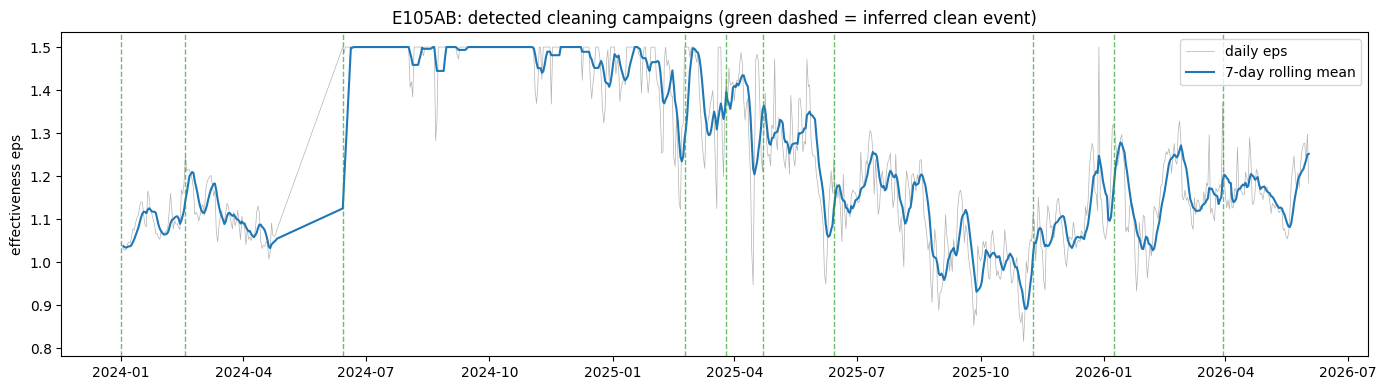

In [8]:
example_hx = max(all_campaigns, key=lambda k: len(all_campaigns[k]))
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(eps.index, eps[example_hx], lw=0.5, color='gray', alpha=0.6, label='daily eps')
ax.plot(eps.index, eps[example_hx].rolling(7, min_periods=3).mean(),
        lw=1.5, color='tab:blue', label='7-day rolling mean')
for c_start, c_end in all_campaigns[example_hx]:
    ax.axvline(c_start, color='tab:green', ls='--', lw=1, alpha=0.7)
ax.set_title(f'{example_hx}: detected cleaning campaigns (green dashed = inferred clean event)')
ax.set_ylabel('effectiveness eps')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Fouling-rate ranking (slope of eps vs days, median across campaigns)

In [9]:
rows = []
for hx, camps in all_campaigns.items():
    slopes = []
    for c_start, c_end in camps:
        s = eps.loc[c_start:c_end, hx].dropna()
        if len(s) < 10:
            continue
        x = (s.index - s.index[0]).days.values.astype(float)
        slope, _ = np.polyfit(x, s.values, 1)
        slopes.append(slope)
    if slopes:
        rows.append({'HX': hx, 'n_campaigns': len(slopes),
                     'median_slope_per_day': np.median(slopes),
                     'mean_eps': eps[hx].mean()})

fouling_rank = pd.DataFrame(rows).sort_values('median_slope_per_day').reset_index(drop=True)
print('most negative slope = fouls fastest')
fouling_rank

most negative slope = fouls fastest


,HX,n_campaigns,median_slope_per_day,mean_eps
0,E112C,8,-0.003432,0.483290
1,E112AB,9,-0.001708,0.427928
2,E105AB,10,-0.001102,1.249760
3,E107AB,5,-0.001009,0.373519
4,E108AB,5,-0.000853,0.329604
5,E104,6,-0.000655,0.435353
6,E109AB,4,-0.000474,0.248110
7,E113A,6,-0.000386,0.205293
8,E111,5,-0.000292,0.340385
9,E101AB,5,-0.000291,0.611837


## 5. Cleaning recommendation (current campaign, project trend forward)

Trigger ตาม CPHT_Cleaning_and_Problem_Control_Plan.docx: clean เมื่อ effectiveness
ลด > 10–15% จาก baseline ของ campaign นั้น ๆ.

In [10]:
TRIGGER_DROP_FRAC = 0.125    # 12.5%, มัธยฐานของช่วง 10–15%

reco_rows = []
last_date = df.index.max()
for hx, camps in all_campaigns.items():
    c_start, c_end = camps[-1]
    s = eps.loc[c_start:c_end, hx].dropna()
    if len(s) < 10:
        continue
    x = (s.index - s.index[0]).days.values.astype(float)
    y = s.values
    slope, intercept = np.polyfit(x, y, 1)
    baseline = np.percentile(y[:max(5, len(y)//10)], 90)
    current  = y[-1]
    drop = (baseline - current) / baseline if baseline else np.nan
    if slope < 0:
        target = baseline * (1 - TRIGGER_DROP_FRAC)
        days = (target - intercept) / slope
        eta = (c_start + pd.Timedelta(days=days)).date()
    else:
        eta = None
    reco_rows.append({
        'HX': hx,
        'campaign_start': c_start.date(),
        'days_in_campaign': (last_date - c_start).days,
        'baseline_eps': round(baseline, 3),
        'current_eps':  round(current, 3),
        'drop_from_baseline_%': round(drop * 100, 1),
        'slope_per_day': round(slope, 5),
        'recommended_clean_by': eta,
        'already_past_trigger': bool(drop >= TRIGGER_DROP_FRAC) if pd.notna(drop) else False,
    })

reco_df = pd.DataFrame(reco_rows).sort_values('drop_from_baseline_%', ascending=False).reset_index(drop=True)
print('as of:', last_date.date())
reco_df

as of: 2026-06-02


,HX,campaign_start,days_in_campaign,baseline_eps,current_eps,drop_from_baseline_%,slope_per_day,recommended_clean_by,already_past_trigger
0,E101EF,2025-12-25,159,0.242,-0.014,105.9,-0.00018,2023-04-12,True
1,E113A,2025-09-25,250,0.319,0.186,41.8,-0.00027,2025-08-11,True
2,E104,2024-11-20,559,0.557,0.354,36.5,-0.00024,2024-07-11,True
3,E112C,2026-01-24,129,0.872,0.573,34.2,-0.00220,2026-02-16,True
4,E111,2025-03-14,445,0.425,0.289,31.9,-0.00018,2025-02-27,True
5,E102,2024-12-05,544,0.113,0.077,31.4,-0.00007,2025-04-23,True
6,E110ABC,2026-01-16,137,0.547,0.411,24.9,-0.00126,2026-02-27,True
7,E109AB,2024-11-10,569,0.301,0.249,17.3,-0.00006,2025-03-23,True
8,E101AB,2025-12-28,156,0.633,0.579,8.6,-0.00035,2026-07-28,False
9,E108AB,2026-02-10,112,0.612,0.562,8.1,0.00019,None,False
